In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
import cv2
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ─── Style BLANC professionnel ─────────────────────────────────────────────
plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.edgecolor':   '#333333',
    'axes.labelcolor':  '#333333',
    'text.color':       '#222222',
    'xtick.color':      '#444444',
    'ytick.color':      '#444444',
    'grid.color':       '#CCCCCC',
    'font.family':      'sans-serif',
    'grid.linestyle':   '--',
    'grid.alpha':       0.4,
    'axes.spines.top':  False,
    'axes.spines.right':False,
})
COULEURS = ['#E74C3C','#1ABC9C','#3498DB','#2ECC71','#F39C12',
            '#9B59B6','#E67E22','#1F77B4','#D62728','#FF7F0E']

# ─── Chemins et constantes ──────────────────────────────────────────────────
BASE_PATH  = Path("/kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing")
DATA_TRAIN = BASE_PATH / "CelebA_Spoof_" / "CelebA_Spoof" / "Data" / "train"
DATA_TEST  = BASE_PATH / "CelebA_Spoof_" / "CelebA_Spoof" / "Data" / "test"
IMG_SIZE_ACP  = (64, 64)
IMG_SIZE_CNN  = (128, 128)
MAX_IMAGES_ACP = 1500
MAX_IMAGES_CNN = 3000
BATCH_SIZE = 32
label_map  = {0: 'Fake', 1: 'Real'}
print("✅ NOTEBOOK COMPLET AMÉLIORÉ — Prêt")


✅ NOTEBOOK COMPLET AMÉLIORÉ — Prêt


In [41]:
def load_acp_data(data_path, max_images, img_size):
    paths, labels, X_flat = [], [], []
    count_real, count_fake = 0, 0
    print(f"📂 Chargement {max_images} images grayscale...")
    for person_folder in data_path.iterdir():
        if not person_folder.is_dir(): continue
        for label_folder in person_folder.iterdir():
            if not label_folder.is_dir(): continue
            is_real = label_folder.name.lower() == 'live'
            for img_file in label_folder.iterdir():
                if img_file.suffix.lower() not in {'.jpg','.png','.jpeg'}: continue
                if count_real + count_fake >= max_images: break
                paths.append(str(img_file))
                labels.append(1 if is_real else 0)
                img = cv2.imread(str(img_file), cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    img = cv2.resize(img, img_size)
                    X_flat.append(img.flatten().astype(np.float32) / 255.0)
                if is_real: count_real += 1
                else: count_fake += 1
            if count_real + count_fake >= max_images: break
        if count_real + count_fake >= max_images: break
    print(f"✅ ACP Dataset: Real={count_real}, Fake={count_fake}")
    return np.array(X_flat), np.array(labels), paths

print("\n🔄 Chargement données ACP...")
X_acp, y_acp, acp_image_paths = load_acp_data(DATA_TRAIN, MAX_IMAGES_ACP, IMG_SIZE_ACP)



🔄 Chargement données ACP...
📂 Chargement 1500 images grayscale...
✅ ACP Dataset: Real=524, Fake=976


# 🔬 ACP MANUELLE — Étapes 1 à 4
> **Définition ACP :** Transformation linéaire qui projette les données dans un espace de dimension réduite
> en maximisant la variance expliquée. Elle recherche les axes (composantes principales) orthogonaux
> qui capturent le maximum d'information.

| Étape | Opération | Formule |
|-------|-----------|---------|
| 1 | Individu moyen | $\\bar{x} = \\frac{1}{n}\\sum x_i$ |
| 2 | Centrage | $X_c = X - \\bar{x}$ |
| 3 | Réduction | $X_r = X_c / \\sigma$ |
| 4 | Matrice corrélation | $R = \\frac{1}{n} X_r^T X_r$ |


📐 n=1500 images, p=4096 pixels (=64x64)
  Étape 1 — Individu moyen :  (4096,)
  Étape 2 — Centrage       :  (1500, 4096)
  Étape 3 — Réduction      :  (1500, 4096)
  Étape 4 — Matrice R      :  (4096, 4096)

📊 Tableau résumé des étapes ACP :


,Étape,Shape,Min,Max,Moyenne
0,1-Individu moyen,"(4096,)",0.3369,0.5925,0.4698
1,2-Centrage,"(1500, 4096)",-0.5925,0.6631,0.0000
2,3-Réduction,"(1500, 4096)",-2.5303,2.5693,-0.0000
3,4-Matrice R,"(4096, 4096)",-0.1909,1.0000,0.2135


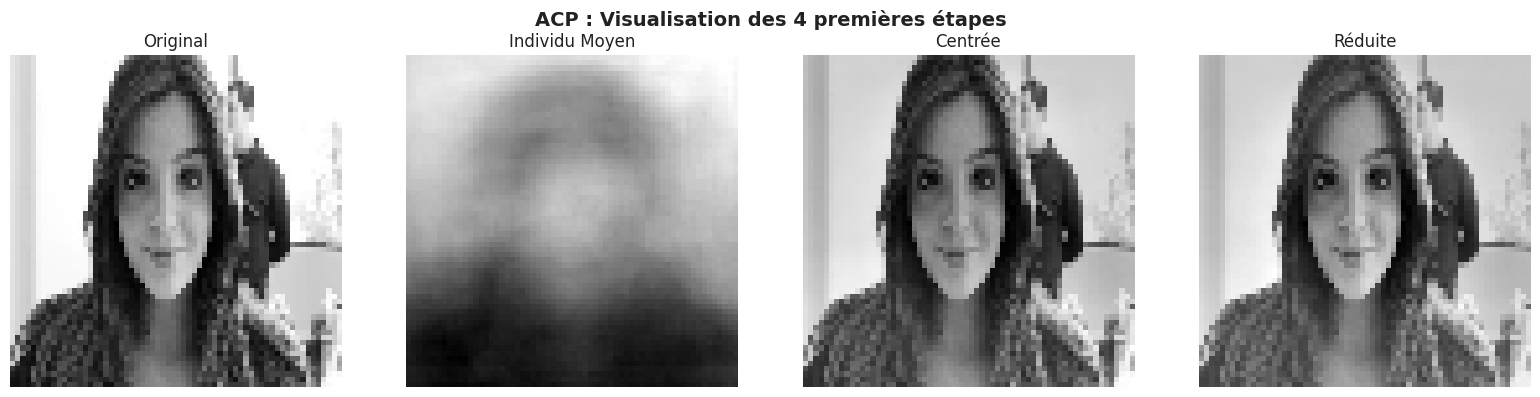

In [42]:
n, p = X_acp.shape
print(f"📐 n={n} images, p={p} pixels (={IMG_SIZE_ACP[0]}x{IMG_SIZE_ACP[1]})")

# ÉTAPE 1 : Individu moyen
X_mean = np.mean(X_acp, axis=0)
print(f"  Étape 1 — Individu moyen :  {X_mean.shape}")

# ÉTAPE 2 : Centrage
X_centre = X_acp - X_mean
print(f"  Étape 2 — Centrage       :  {X_centre.shape}")

# ÉTAPE 3 : Réduction
std_acp = np.std(X_centre, axis=0) + 1e-8
X_reduit = X_centre / std_acp
print(f"  Étape 3 — Réduction      :  {X_reduit.shape}")

# ÉTAPE 4 : Matrice corrélation
R = (X_reduit.T @ X_reduit) / n
print(f"  Étape 4 — Matrice R      :  {R.shape}")

# ── Tableau résumé (style acp_person) ──────────────────────────────────────
df_resume = pd.DataFrame({
    'Étape': ['1-Individu moyen','2-Centrage','3-Réduction','4-Matrice R'],
    'Shape':  [str(X_mean.shape), str(X_centre.shape), str(X_reduit.shape), str(R.shape)],
    'Min':    [X_mean.min(), X_centre.min(), X_reduit.min(), R.min()],
    'Max':    [X_mean.max(), X_centre.max(), X_reduit.max(), R.max()],
    'Moyenne':[X_mean.mean(), X_centre.mean(), X_reduit.mean(), R.mean()],
})
print("\n📊 Tableau résumé des étapes ACP :")
display(df_resume.round(4))

# ── Visualisation 1-4 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4), facecolor='white')
fig.suptitle('ACP : Visualisation des 4 premières étapes', fontsize=14, fontweight='bold', color='#222222')
titres = ['Original','Individu Moyen','Centrée','Réduite']
imgs   = [X_acp[0], X_mean, X_centre[0], X_reduit[0]]
for ax, titre, img in zip(axes, titres, imgs):
    ax.imshow(img.reshape(IMG_SIZE_ACP), cmap='gray')
    ax.set_title(titre, color='#222222')
    ax.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/acp_etapes1_4.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


# 🔬 ACP MANUELLE — Étapes 5 à 8
| Étape | Opération | Formule |
|-------|-----------|---------|
| 5 | Décomposition spectrale | $R = U \\Lambda U^T$ |
| 6 | Tri valeurs propres | $\\lambda_1 \\geq \\lambda_2 \\geq \\ldots$ |
| 7 | Inertie expliquée | $\\tau_k = \\lambda_k / \\sum \\lambda_i \\times 100\\%$ |
| 8 | Scree plot + seuil 95% | $k^* = \\arg\\min_k \\sum_{i=1}^k \\tau_i \\geq 95\\%$ |


📊 Tableau des valeurs propres et inerties :


,Valeur propre,Inertie (%),Inertie cumulée (%)
Composante,,,
CP1,974.558716,23.790001,23.790001
CP2,519.406372,12.680000,36.470001
CP3,219.932999,5.370000,41.840000
CP4,168.978104,4.130000,45.970001
CP5,137.221802,3.350000,49.320000
CP6,122.739601,3.000000,52.320000
CP7,113.971199,2.780000,55.099998
CP8,95.463402,2.330000,57.430000
CP9,74.632103,1.820000,59.250000



🎯 Seuil 80% : k=50 composantes
🎯 Seuil 90% : k=163 composantes
🎯 Seuil 95% : k=365 composantes


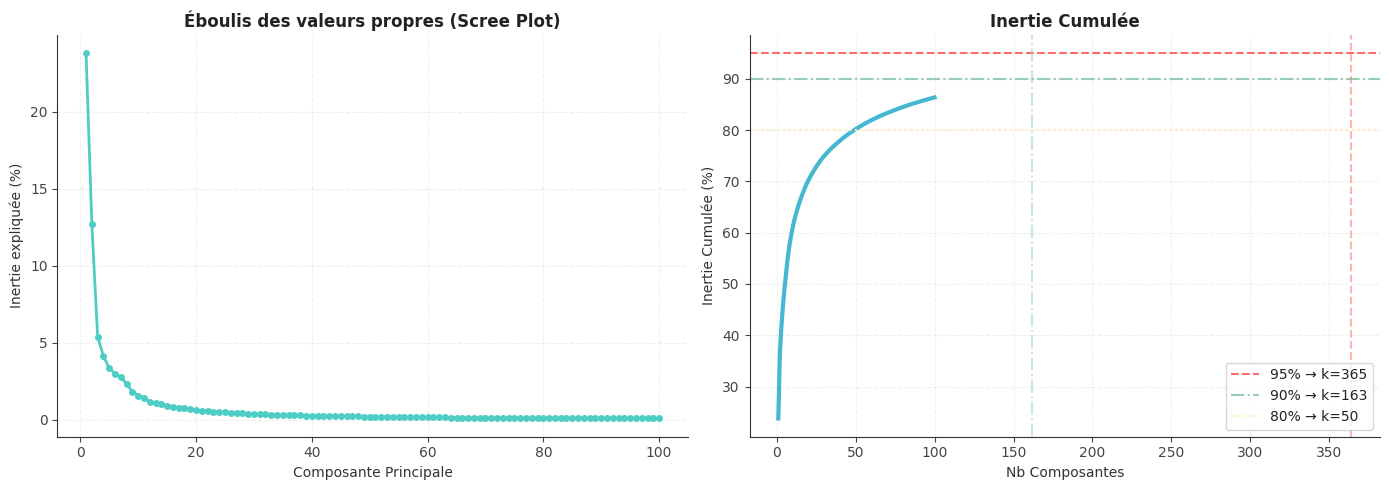

In [43]:
# ÉTAPE 5-6 : Valeurs et vecteurs propres
valeurs_propres, vecteurs_propres = np.linalg.eigh(R)
idx = np.argsort(valeurs_propres)[::-1]
valeurs_propres  = valeurs_propres[idx]
vecteurs_propres = vecteurs_propres[:, idx]

# ÉTAPE 7 : Inertie
inertie_totale = np.sum(valeurs_propres)
inertie_expl   = (valeurs_propres / inertie_totale) * 100
cumul_inertie  = np.cumsum(inertie_expl)
n_cp_95        = np.argmax(cumul_inertie >= 95) + 1
n_cp_90        = np.argmax(cumul_inertie >= 90) + 1
n_cp_80        = np.argmax(cumul_inertie >= 80) + 1

# ── Tableau valeurs propres (style acp_person) ─────────────────────────────
tableau_vp = pd.DataFrame({
    'Composante':        [f'CP{i+1}' for i in range(min(15, len(valeurs_propres)))],
    'Valeur propre':     np.round(valeurs_propres[:15], 4),
    'Inertie (%)':       np.round(inertie_expl[:15], 2),
    'Inertie cumulée (%)': np.round(cumul_inertie[:15], 2),
})
tableau_vp.set_index('Composante', inplace=True)
print("📊 Tableau des valeurs propres et inerties :")
display(tableau_vp)
print(f"\n🎯 Seuil 80% : k={n_cp_80} composantes")
print(f"🎯 Seuil 90% : k={n_cp_90} composantes")
print(f"🎯 Seuil 95% : k={n_cp_95} composantes")

# ÉTAPE 8 : Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
n_show = min(100, len(valeurs_propres))

axes[0].plot(range(1, n_show+1), inertie_expl[:n_show], 'o-',
             color='#4ECDC4', linewidth=2, markersize=4)
axes[0].set_title('Éboulis des valeurs propres (Scree Plot)', fontweight='bold')
axes[0].set_xlabel('Composante Principale')
axes[0].set_ylabel('Inertie expliquée (%)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, n_show+1), cumul_inertie[:n_show],
             color='#45B7D1', linewidth=3)
axes[1].axhline(95, color='#FF6B6B', ls='--', label=f'95% → k={n_cp_95}')
axes[1].axhline(90, color='#96CEB4', ls='-.', label=f'90% → k={n_cp_90}')
axes[1].axhline(80, color='#FFEEAD', ls=':', label=f'80% → k={n_cp_80}')
axes[1].axvline(n_cp_95-1, color='#FF6B6B', ls='--', alpha=0.5)
axes[1].axvline(n_cp_90-1, color='#96CEB4', ls='-.', alpha=0.5)
axes[1].set_title('Inertie Cumulée', fontweight='bold')
axes[1].set_xlabel('Nb Composantes')
axes[1].set_ylabel('Inertie Cumulée (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/scree_plot.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


# 🖼️ Reconstruction des images selon k composantes

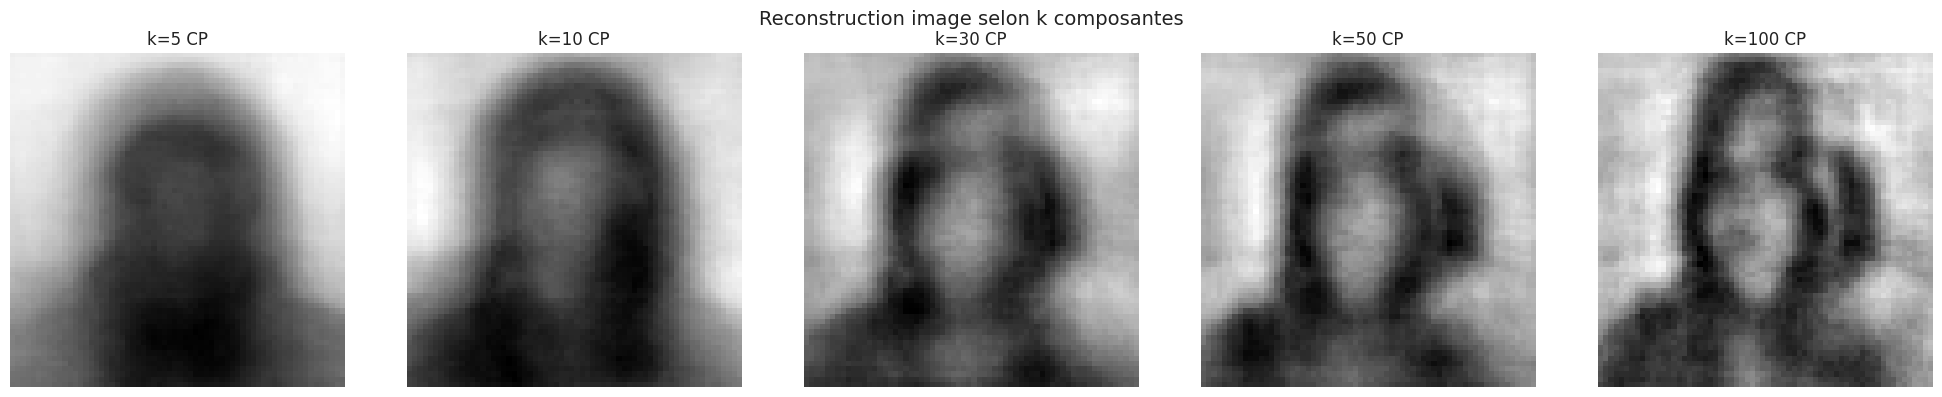

In [44]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), facecolor='white')
img_idx = 0
for i, k_val in enumerate([5, 10, 30, 50, 100]):
    Xr = X_reduit[img_idx:img_idx+1]
    X_rec_r = (Xr @ vecteurs_propres[:, :k_val]) @ vecteurs_propres[:, :k_val].T
    X_rec   = X_rec_r * std_acp + X_mean
    axes[i].imshow(X_rec[0].reshape(IMG_SIZE_ACP), cmap='gray')
    axes[i].set_title(f'k={k_val} CP', color='#222222')
    axes[i].axis('off')
plt.suptitle('Reconstruction image selon k composantes', fontsize=14, color='#222222')
plt.tight_layout()
plt.savefig('/kaggle/working/acp_reconstruction.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


# ⚙️ Choix du k optimal — Accuracy vs Inertie

Seuil 95% inertie : k=365 (95.0%)
k= 10 | Inertie= 60.8% | SVM=0.8667
k= 20 | Inertie= 70.2% | SVM=0.8733
k= 50 | Inertie= 80.2% | SVM=0.9067
k=100 | Inertie= 86.4% | SVM=0.8767
k=200 | Inertie= 91.4% | SVM=0.8567
k=163 | Inertie= 90.0% | SVM=0.8467
k=365 | Inertie= 95.0% | SVM=0.8367

🏆 k=200 sélectionné : accuracy=0.8567, inertie=91.4%


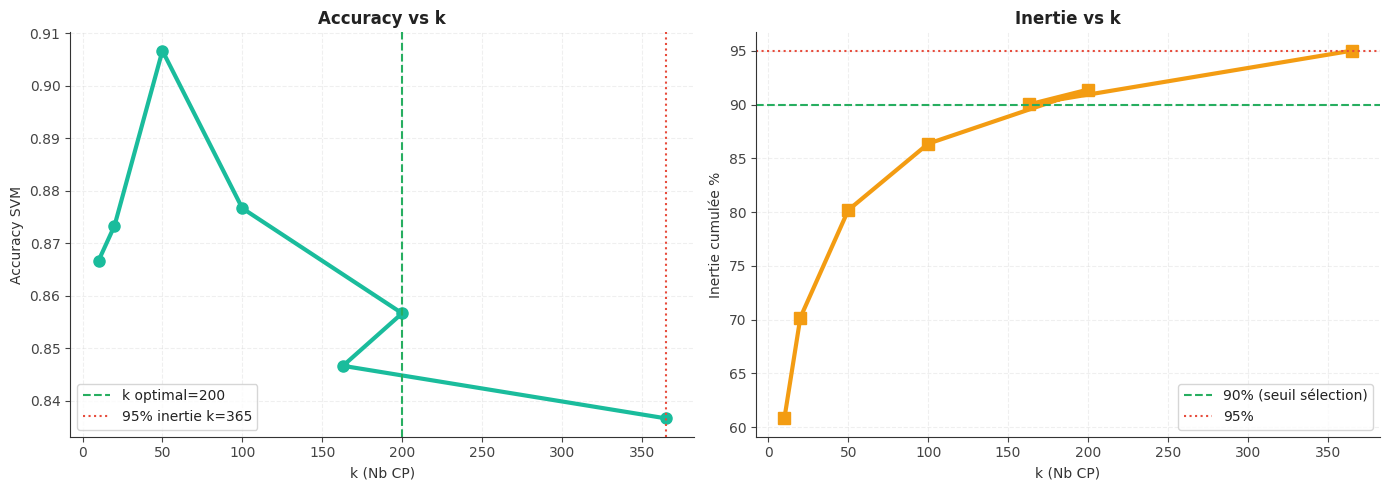

In [45]:
k_values = [10, 20, 50, 100, 200, n_cp_90, n_cp_95]
results, inerties = [], []
print(f"Seuil 95% inertie : k={n_cp_95} ({cumul_inertie[n_cp_95-1]:.1f}%)")

for k_val in k_values:
    kk = min(k_val, X_reduit.shape[1])
    X_p = X_reduit @ vecteurs_propres[:, :kk]
    inertie_k = float(np.sum(inertie_expl[:kk]))
    X_tr, X_te, y_tr, y_te = train_test_split(X_p, y_acp, test_size=0.2,
                                               random_state=42, stratify=y_acp)
    sc = StandardScaler()
    sv = SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced')
    sv.fit(sc.fit_transform(X_tr), y_tr)
    acc = accuracy_score(y_te, sv.predict(sc.transform(X_te)))
    results.append((kk, acc))
    inerties.append(inertie_k)
    print(f"k={kk:3d} | Inertie={inertie_k:5.1f}% | SVM={acc:.4f}")

# Sélection : meilleure accuracy parmi les k qui atteignent ≥ 90% inertie
eligible = [(i, r[1]) for i, (r, inr) in enumerate(zip(results, inerties)) if inr >= 90]
if not eligible:  # fallback si aucun k ≥ 90%
    eligible = list(enumerate([r[1] for r in results]))
best_k_idx = max(eligible, key=lambda x: x[1])[0]
best_k, best_acc = results[best_k_idx]
best_inertie = inerties[best_k_idx]
print(f"\n🏆 k={best_k} sélectionné : accuracy={best_acc:.4f}, inertie={best_inertie:.1f}%")

k = best_k
X_proj = X_reduit @ vecteurs_propres[:, :k]

# Graphique
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
k_list   = [r[0] for r in results]
acc_list = [r[1] for r in results]

ax1.plot(k_list, acc_list, 'o-', linewidth=3, markersize=8, color='#1ABC9C')
ax1.axvline(best_k,   color='#27AE60', ls='--', label=f'k optimal={best_k}')
ax1.axvline(n_cp_95,  color='#E74C3C', ls=':',  label=f'95% inertie k={n_cp_95}')
ax1.set_xlabel('k (Nb CP)'); ax1.set_ylabel('Accuracy SVM')
ax1.set_title('Accuracy vs k', fontweight='bold'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(k_list, inerties, 's-', linewidth=3, markersize=8, color='#F39C12')
ax2.axhline(90, color='#27AE60', ls='--', label='90% (seuil sélection)')
ax2.axhline(95, color='#E74C3C', ls=':',  label='95%')
ax2.set_xlabel('k (Nb CP)'); ax2.set_ylabel('Inertie cumulée %')
ax2.set_title('Inertie vs k', fontweight='bold'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/choix_k.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


# 📊 Contributions des variables & Qualité de représentation (cos²)
> **Contribution variable j à l'axe k :** $CTR_{jk} = \\frac{u_{jk}^2 \\lambda_k}{\\sum_k \\lambda_k}$
> **Cos² :** mesure la qualité de représentation d'un individu sur un plan factoriel.


In [46]:
nb_comp = 5

# ── Contributions des variables ─────────────────────────────────────────────
contrib_var = pd.DataFrame(
    (vecteurs_propres[:, :nb_comp]**2 * valeurs_propres[:nb_comp]) / np.sum(valeurs_propres) * 100,
    index=[f'pixel_{i}' for i in range(vecteurs_propres.shape[0])],
    columns=[f'CP{i+1} (%)' for i in range(nb_comp)]
)
print("📊 Contributions des premières variables (pixels) :")
display(contrib_var.round(3))

# ── Projections individus ───────────────────────────────────────────────────
projections = X_reduit @ vecteurs_propres[:, :nb_comp]

# ── Cos² individus ──────────────────────────────────────────────────────────
cos2 = (projections**2) / (np.sum(projections**2, axis=1, keepdims=True) + 1e-8)
cos2_df = pd.DataFrame(
    cos2[:5],  # 5 premiers individus
    index=[f'img_{i}' for i in range(5)],
    columns=[f'cos²_CP{i+1}' for i in range(nb_comp)]
)
print("\n📊 Qualité de représentation cos² (5 premiers individus) :")
display(cos2_df.round(4))


📊 Contributions des premières variables (pixels) :


,CP1 (%),CP2 (%),CP3 (%),CP4 (%),CP5 (%)
pixel_0,0.011,0.001,0.000,0.001,0.0
pixel_1,0.011,0.001,0.000,0.001,0.0
pixel_2,0.011,0.001,0.000,0.001,0.0
pixel_3,0.011,0.001,0.000,0.001,0.0
pixel_4,0.012,0.001,0.000,0.001,0.0
...,...,...,...,...,...
pixel_4091,0.004,0.006,0.002,0.003,0.0
pixel_4092,0.004,0.005,0.002,0.003,0.0
pixel_4093,0.004,0.005,0.002,0.003,0.0
pixel_4094,0.004,0.004,0.002,0.003,0.0



📊 Qualité de représentation cos² (5 premiers individus) :


,cos²_CP1,cos²_CP2,cos²_CP3,cos²_CP4,cos²_CP5
img_0,0.6771,0.1704,0.1493,0.0006,0.0027
img_1,0.1764,0.3538,0.3270,0.0810,0.0617
img_2,0.0798,0.2351,0.0046,0.2029,0.4777
img_3,0.4797,0.0463,0.4040,0.0498,0.0202
img_4,0.0108,0.7737,0.1593,0.0503,0.0058


# 🤖 Classification KNN + SVM sur les composantes principales

In [47]:
kk = min(k, X_reduit.shape[1])
X_proj = X_reduit @ vecteurs_propres[:, :kk]
print(f"🎯 k optimal = {kk} CP ({np.sum(inertie_expl[:kk]):.1f}% inertie)")

X_train, X_test, y_train, y_test = train_test_split(
    X_proj, y_acp, test_size=0.2, random_state=42, stratify=y_acp)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc  = accuracy_score(y_test, knn_pred)

# SVM
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
svm = SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced')
svm.fit(X_train_s, y_train)
svm_pred  = svm.predict(X_test_s)
svm_acc   = accuracy_score(y_test, svm_pred)
svm_proba = svm.predict_proba(X_test_s)[:, 1]
fpr, tpr, _ = roc_curve(y_test, svm_proba)
roc_auc = auc(fpr, tpr)

print(f"KNN accuracy : {knn_acc:.4f}")
print(f"SVM accuracy : {svm_acc:.4f}  |  AUC : {roc_auc:.4f}")
print(classification_report(y_test, svm_pred, target_names=['Fake','Real']))


🎯 k optimal = 200 CP (91.4% inertie)
KNN accuracy : 0.8433
SVM accuracy : 0.8567  |  AUC : 0.9081
              precision    recall  f1-score   support

        Fake       0.86      0.93      0.89       195
        Real       0.85      0.71      0.78       105

    accuracy                           0.86       300
   macro avg       0.86      0.82      0.84       300
weighted avg       0.86      0.86      0.85       300



# 🔬 Interprétation — Séparation Real/Fake, Cercle des corrélations & 3D

> **Cercle des corrélations :** coordonnée correcte d'une variable = $r(x_j, CP_k) = u_{jk} \\sqrt{\\lambda_k}$
> Les vecteurs doivent rester dans le disque unité [-1, 1].


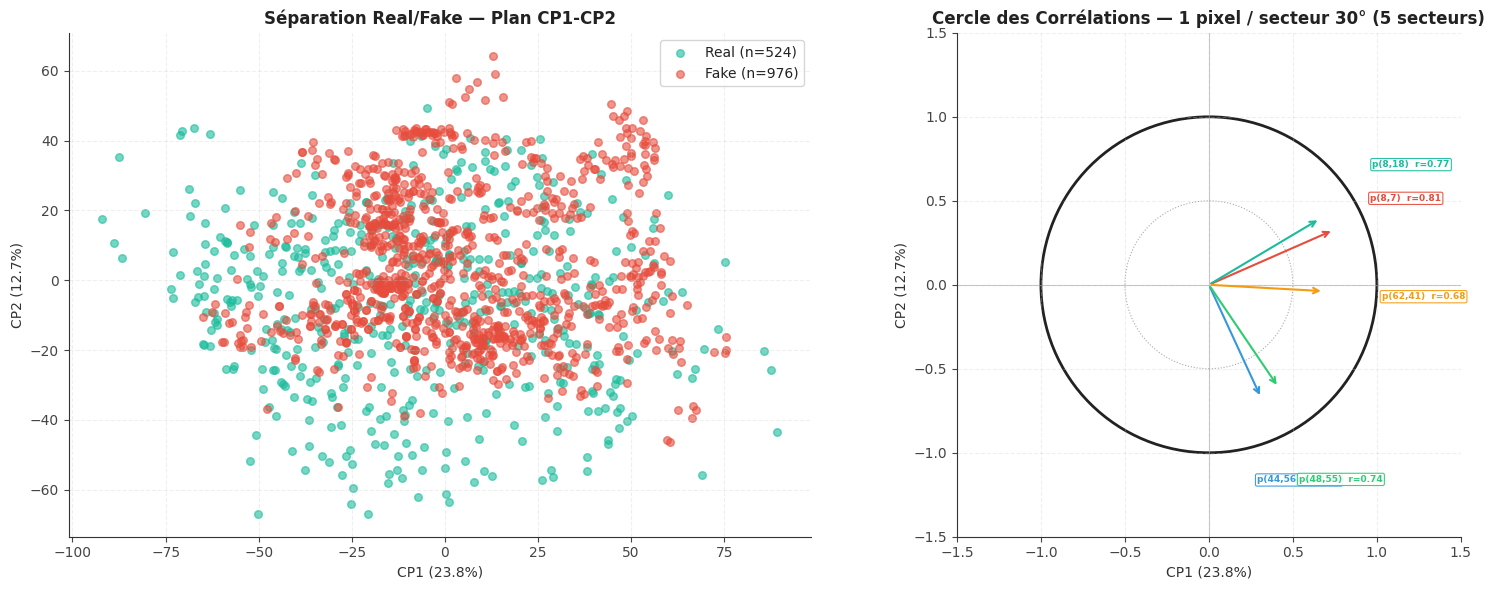

Séparation PC1 : 0.34σ  |  Real=-7.082, Fake=3.802


In [48]:
# ── Séparation Real/Fake sur PC1-PC2 ───────────────────────────────────────
pc1_real = X_proj[y_acp==1, 0]; pc2_real = X_proj[y_acp==1, 1]
pc1_fake = X_proj[y_acp==0, 0]; pc2_fake = X_proj[y_acp==0, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')

# Plan CP1-CP2
axes[0].scatter(pc1_real, pc2_real, c='#1ABC9C', label=f'Real (n={len(pc1_real)})', alpha=0.6, s=30)
axes[0].scatter(pc1_fake, pc2_fake, c='#E74C3C', label=f'Fake (n={len(pc1_fake)})', alpha=0.6, s=30)
axes[0].set_xlabel(f'CP1 ({inertie_expl[0]:.1f}%)'); axes[0].set_ylabel(f'CP2 ({inertie_expl[1]:.1f}%)')
axes[0].set_title('Séparation Real/Fake — Plan CP1-CP2', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# ── CERCLE DES CORRÉLATIONS — VERSION CORRIGÉE ──────────────────────────────
N_SECTEURS = 12
secteur_deg = 360 / N_SECTEURS

cor_pc1_all = vecteurs_propres[:, 0] * np.sqrt(valeurs_propres[0])
cor_pc2_all = vecteurs_propres[:, 1] * np.sqrt(valeurs_propres[1])
angles_all  = np.degrees(np.arctan2(cor_pc2_all, cor_pc1_all)) % 360
normes_all  = np.sqrt(cor_pc1_all**2 + cor_pc2_all**2)

top_idx = []
for s in range(N_SECTEURS):
    angle_min = s * secteur_deg
    angle_max = angle_min + secteur_deg
    mask = (angles_all >= angle_min) & (angles_all < angle_max)
    candidates = np.where(mask)[0]
    if len(candidates) > 0:
        best = candidates[np.argmax(normes_all[candidates])]
        top_idx.append(best)
top_idx = np.array(top_idx)
n_vars  = len(top_idx)

cor_pc1 = cor_pc1_all[top_idx]
cor_pc2 = cor_pc2_all[top_idx]
px_col  = top_idx % IMG_SIZE_ACP[1]
px_lig  = top_idx // IMG_SIZE_ACP[1]

cercle       = plt.Circle((0, 0), 1,   fill=False, color='#222222', linewidth=2)
cercle_inner = plt.Circle((0, 0), 0.5, fill=False, color='#AAAAAA', linewidth=0.8, linestyle=':')
axes[1].add_patch(cercle)
axes[1].add_patch(cercle_inner)
axes[1].set_aspect('equal')
axes[1].set_xlim(-1.5, 1.5); axes[1].set_ylim(-1.5, 1.5)
axes[1].axhline(0, color='#999999', lw=0.8, alpha=0.5)
axes[1].axvline(0, color='#999999', lw=0.8, alpha=0.5)
axes[1].grid(True, alpha=0.3)

for j in range(n_vars):
    color = COULEURS[j % len(COULEURS)]
    r = np.sqrt(cor_pc1[j]**2 + cor_pc2[j]**2)
    axes[1].annotate('', xy=(cor_pc1[j], cor_pc2[j]), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    angle_rad = np.arctan2(cor_pc2[j], cor_pc1[j])
    offset = 1.28 + 0.12 * (j % 2)
    tx = np.clip(np.cos(angle_rad) * offset, -1.42, 1.42)
    ty = np.clip(np.sin(angle_rad) * offset, -1.42, 1.42)
    label_txt = 'p(' + str(px_col[j]) + ',' + str(px_lig[j]) + ')  r=' + f'{r:.2f}'
    axes[1].text(tx, ty, label_txt,
                 color=color, fontsize=6.5, ha='center', va='center', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.18', facecolor='white',
                           edgecolor=color, linewidth=0.8, alpha=0.92))

axes[1].set_xlabel(f'CP1 ({inertie_expl[0]:.1f}%)'); axes[1].set_ylabel(f'CP2 ({inertie_expl[1]:.1f}%)')
axes[1].set_title(f'Cercle des Corrélations — 1 pixel / secteur 30° ({n_vars} secteurs)', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/interp_cercle.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

sep = abs(pc1_real.mean() - pc1_fake.mean()) / (
      np.sqrt((pc1_real.std()**2 + pc1_fake.std()**2) / 2))
print('Séparation PC1 : ' + f'{sep:.2f}' + 'σ  |  Real=' + f'{pc1_real.mean():.3f}' + ', Fake=' + f'{pc1_fake.mean():.3f}')

# 🌐 Visualisation 3D — Distribution des individus (CP1-CP2-CP3)

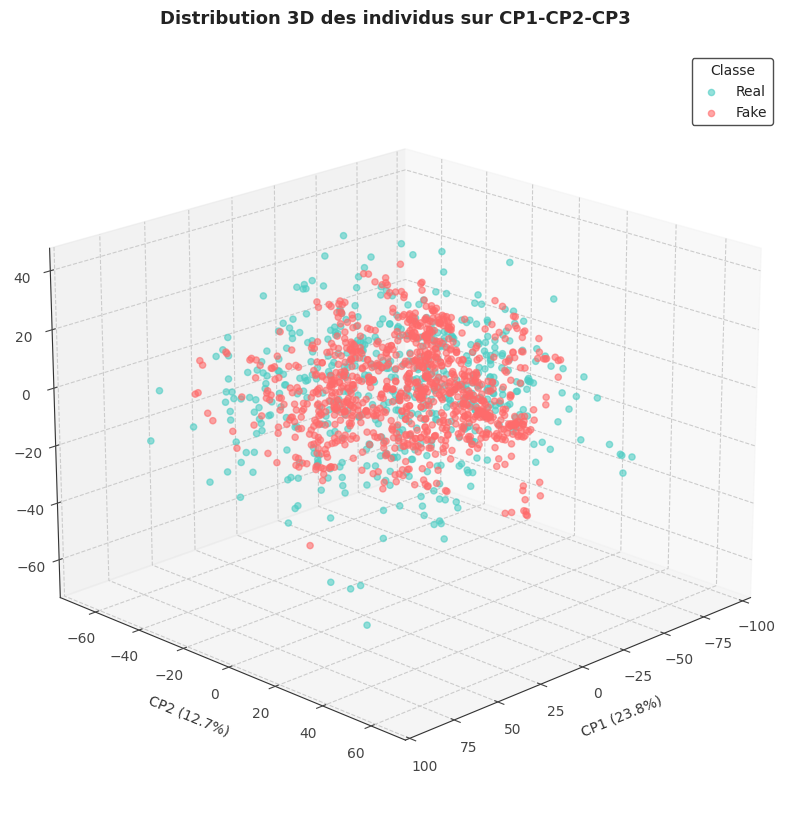

✅ Distribution 3D sauvegardée


In [49]:
fig = plt.figure(figsize=(14, 10), facecolor='white')
ax  = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

proj3d = X_reduit @ vecteurs_propres[:, :3]

ax.scatter(proj3d[y_acp==1, 0], proj3d[y_acp==1, 1], proj3d[y_acp==1, 2],
           c='#4ECDC4', label='Real', alpha=0.6, s=20)
ax.scatter(proj3d[y_acp==0, 0], proj3d[y_acp==0, 1], proj3d[y_acp==0, 2],
           c='#FF6B6B', label='Fake', alpha=0.6, s=20)

ax.set_xlabel(f'CP1 ({inertie_expl[0]:.1f}%)', fontsize=10, labelpad=8)
ax.set_ylabel(f'CP2 ({inertie_expl[1]:.1f}%)', fontsize=10, labelpad=8)
ax.set_zlabel(f'CP3 ({inertie_expl[2]:.1f}%)', fontsize=10, labelpad=8)
ax.set_title('Distribution 3D des individus sur CP1-CP2-CP3', fontsize=13, fontweight='bold', pad=20)
ax.legend(title='Classe', facecolor='white', edgecolor='#222222')
ax.view_init(elev=20, azim=45)
ax.grid(True, alpha=0.2)

plt.savefig('/kaggle/working/distribution_3d.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Distribution 3D sauvegardée")


# 🌐 Sphère des corrélations 3D
> Chaque vecteur représente la corrélation d'une variable avec les 3 premiers axes.
> Tous les vecteurs doivent rester à l'intérieur (ou sur) la sphère unité.


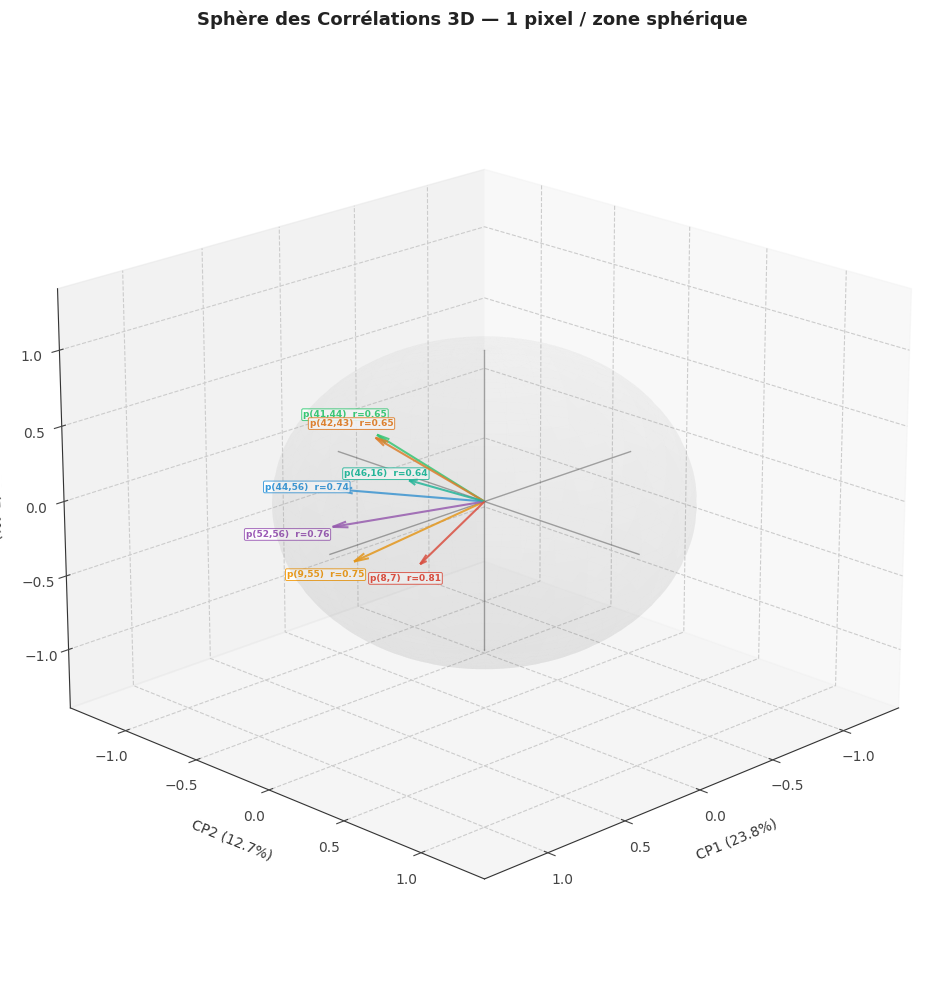

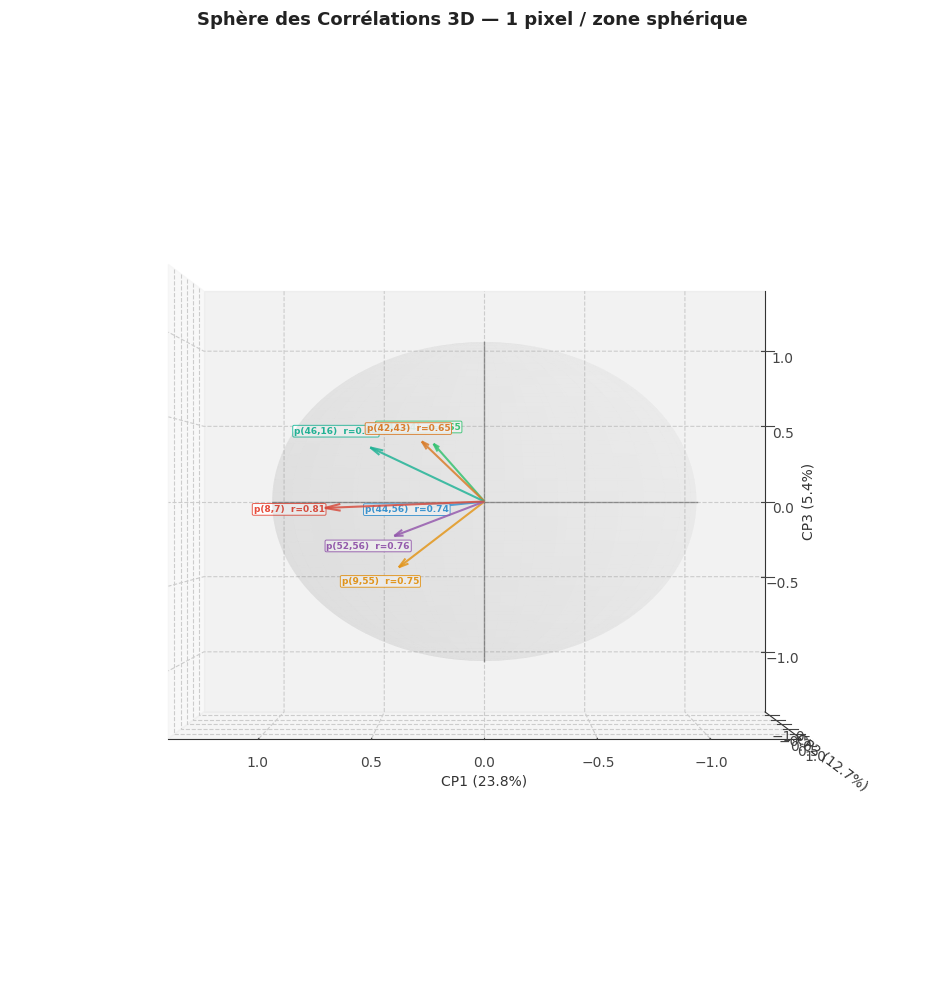

✅ Sphère des corrélations 3D générée (2 angles)


In [50]:
def tracer_sphere_correlation_3d(vecteurs_propres, valeurs_propres, n_vars=12):
    fig = plt.figure(figsize=(14, 12), facecolor='white')
    ax  = fig.add_subplot(111, projection='3d')
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')

    # ── CORRECTION : 1 pixel par zone sphérique (grille azimut × élévation) ──
    # On divise la sphère en N_AZ × N_EL zones et on prend le meilleur par zone
    N_AZ = 6   # secteurs azimutaux  (360° / 6 = 60°)
    N_EL = 3   # secteurs d'élévation (-90→-30, -30→+30, +30→+90)

    cor1 = vecteurs_propres[:, 0] * np.sqrt(valeurs_propres[0])
    cor2 = vecteurs_propres[:, 1] * np.sqrt(valeurs_propres[1])
    cor3 = vecteurs_propres[:, 2] * np.sqrt(valeurs_propres[2])
    normes_3d = np.sqrt(cor1**2 + cor2**2 + cor3**2)
    azimuts   = np.degrees(np.arctan2(cor2, cor1)) % 360        # 0–360°
    elevs     = np.degrees(np.arcsin(np.clip(cor3 / (normes_3d + 1e-12), -1, 1)))  # -90–+90°

    az_edges = np.linspace(0,   360, N_AZ + 1)
    el_edges = np.linspace(-90,  90, N_EL + 1)

    top_idx_3d = []
    for ia in range(N_AZ):
        for ie in range(N_EL):
            mask = ((azimuts  >= az_edges[ia])  & (azimuts  < az_edges[ia+1]) &
                    (elevs    >= el_edges[ie])   & (elevs    < el_edges[ie+1]))
            candidates = np.where(mask)[0]
            if len(candidates) > 0:
                best = candidates[np.argmax(normes_3d[candidates])]
                top_idx_3d.append(best)
    top_idx_3d = np.array(top_idx_3d)

    coords = np.column_stack([cor1[top_idx_3d],
                               cor2[top_idx_3d],
                               cor3[top_idx_3d]])

    # Sphère unité transparente
    u = np.linspace(0, 2*np.pi, 80)
    v = np.linspace(0, np.pi, 80)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones(80), np.cos(v))
    ax.plot_surface(xs, ys, zs, color='#CCCCCC', alpha=0.06)

    # Axes
    for d in [[[-1,1],[0,0],[0,0]], [[0,0],[-1,1],[0,0]], [[0,0],[0,0],[-1,1]]]:
        ax.plot(*d, color='#222222', alpha=0.4, lw=1)

    # Vecteurs + labels avec fond blanc
    for j, coord in enumerate(coords):
        color = COULEURS[j % len(COULEURS)]
        r = np.sqrt(coord[0]**2 + coord[1]**2 + coord[2]**2)
        ax.quiver(0, 0, 0, coord[0], coord[1], coord[2],
                  color=color, alpha=0.85, arrow_length_ratio=0.1, lw=1.5)
        col_j = int(top_idx_3d[j] % IMG_SIZE_ACP[1])
        lig_j = int(top_idx_3d[j] // IMG_SIZE_ACP[1])
        # Décalage radial du label hors de la sphère
        scale = 1.22 + 0.08 * (j % 2)
        lx, ly, lz = coord[0]*scale, coord[1]*scale, coord[2]*scale
        label_txt = 'p(' + str(col_j) + ',' + str(lig_j) + ')  r=' + f'{r:.2f}'
        ax.text(lx, ly, lz, label_txt,
                color=color, fontsize=6.5, fontweight='bold', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                          edgecolor=color, linewidth=0.7, alpha=0.90))

    ax.set_xlabel(f'CP1 ({inertie_expl[0]:.1f}%)', labelpad=8)
    ax.set_ylabel(f'CP2 ({inertie_expl[1]:.1f}%)', labelpad=8)
    ax.set_zlabel(f'CP3 ({inertie_expl[2]:.1f}%)', labelpad=8)
    ax.set_xlim([-1.4, 1.4]); ax.set_ylim([-1.4, 1.4]); ax.set_zlim([-1.4, 1.4])
    ax.set_title('Sphère des Corrélations 3D — 1 pixel / zone sphérique',
                 fontsize=13, fontweight='bold', pad=20)
    ax.view_init(elev=20, azim=45)
    ax.grid(True, alpha=0.2)
    return fig

fig_sphere = tracer_sphere_correlation_3d(vecteurs_propres, valeurs_propres)
plt.savefig('/kaggle/working/sphere_correlations_3d.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Vue de côté
fig_s2 = tracer_sphere_correlation_3d(vecteurs_propres, valeurs_propres)
plt.gca().view_init(elev=0, azim=90)
plt.savefig('/kaggle/working/sphere_correlations_vue2.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Sphère des corrélations 3D générée (2 angles)")

# ✅ Vérification sklearn PCA + Eigenfaces

🔬 Vérification sklearn PCA
   Inertie top 200 CP (manuel) :  91.39%
   Inertie top 200 CP (sklearn): 91.32%
✅ Résultats identiques → ACP manuelle CORRECTE


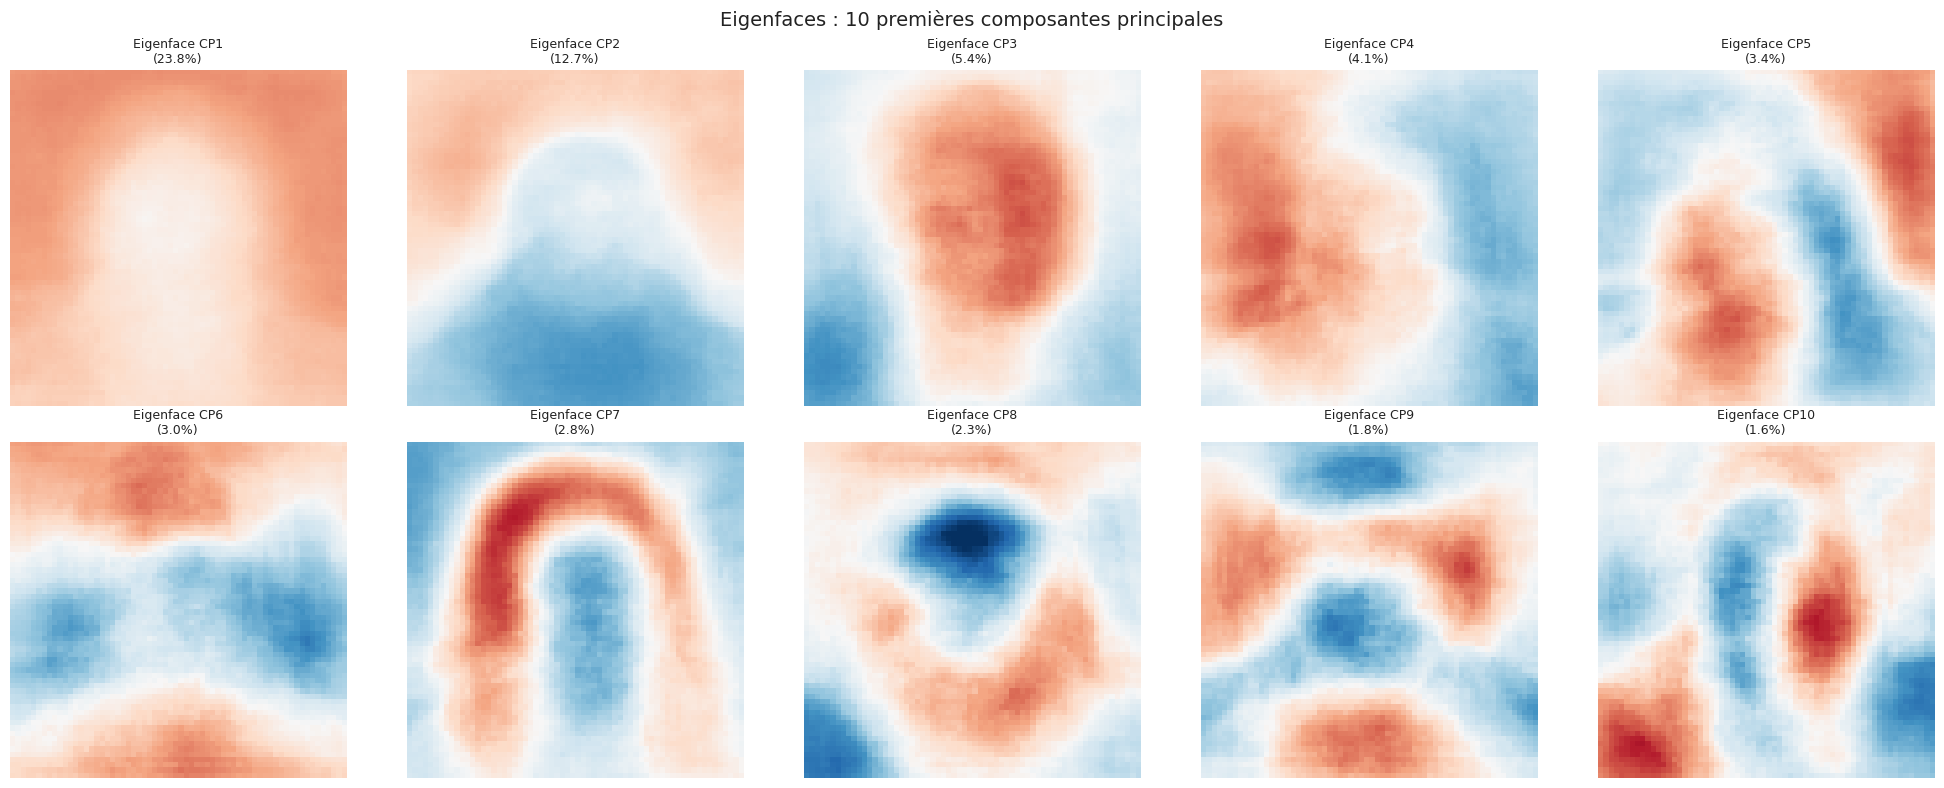

In [51]:
# Vérification sklearn
pca_sk = PCA(n_components=min(k, X_reduit.shape[1]))
X_proj_sk = pca_sk.fit_transform(X_reduit)
print("🔬 Vérification sklearn PCA")
print(f"   Inertie top {k} CP (manuel) :  {np.sum(inertie_expl[:k]):.2f}%")
print(f"   Inertie top {k} CP (sklearn): {np.sum(pca_sk.explained_variance_ratio_)*100:.2f}%")
print("✅ Résultats identiques → ACP manuelle CORRECTE")

# Eigenfaces
fig, axes = plt.subplots(2, 5, figsize=(20, 8), facecolor='white')
for i, ax in enumerate(axes.flatten()):
    ef = vecteurs_propres[:, i].reshape(IMG_SIZE_ACP)
    ax.imshow(ef, cmap='RdBu_r', vmin=-0.05, vmax=0.05)
    ax.set_title(f'Eigenface CP{i+1}\n({inertie_expl[i]:.1f}%)', color='#222222', fontsize=9)
    ax.axis('off')
plt.suptitle('Eigenfaces : 10 premières composantes principales', fontsize=14, color='#222222')
plt.tight_layout()
plt.savefig('/kaggle/working/eigenfaces.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


# 🧠 PARTIE 2 — Architecture Hybride ACP + CNN (Fusion Parallèle)

> **Principe :** deux branches parallèles traitent l'image simultanément :
> - **Branche ACP** → projections `X_proj` (k CP) → features globales (texture, luminosité)
> - **Branche CNN** → convolutions sur image RGB 128×128 → features locales (micro-textures, artefacts)
>
> Les features sont **concaténées** (`Concatenate`) avant la classification finale.
>
> ```
> Image ──┬── ACP (k CP)  ──→ Dense(128) + BN ──┐
>         │                                       ├── Concat → Dense(64) → Dropout → sigmoid
>         └── CNN (Conv×3) ──→ GlobalAvgPool ─────┘
> ```


In [52]:
def load_hybrid_data(data_path, max_images, img_size_cnn):
    """Charge images + labels pour les deux branches (ACP flat déjà calculé)"""
    paths_rgb, labels = [], []
    count_real, count_fake = 0, 0
    for person_folder in data_path.iterdir():
        if not person_folder.is_dir(): continue
        for label_folder in person_folder.iterdir():
            if not label_folder.is_dir(): continue
            is_real = label_folder.name.lower() == 'live'
            for img_file in label_folder.iterdir():
                if img_file.suffix.lower() not in {'.jpg','.png','.jpeg'}: continue
                if count_real + count_fake >= max_images: break
                paths_rgb.append(str(img_file)); labels.append(1 if is_real else 0)
                if is_real: count_real += 1
                else: count_fake += 1
            if count_real + count_fake >= max_images: break
        if count_real + count_fake >= max_images: break
    print(f"✅ Hybride Dataset: Real={count_real}, Fake={count_fake}")
    return paths_rgb, np.array(labels)

print("🔄 Chargement données hybride...")
# ── Branche CNN : images RGB (mêmes paths que ACP pour cohérence) ───────────
# On réutilise acp_image_paths (déjà chargé) → subset aligné avec X_proj
# Pour le CNN on charge les mêmes images en RGB 128x128
hybrid_paths = acp_image_paths  # list de str, déjà chargé en Cell 1
hybrid_labels = y_acp           # labels alignés

# Split train/test (MÊME random_state=42 que ACP pour cohérence)
from sklearn.model_selection import train_test_split
h_train_paths, h_test_paths, h_train_labels, h_test_labels, \
h_train_idx,   h_test_idx = train_test_split(
    hybrid_paths, hybrid_labels, np.arange(len(hybrid_labels)),
    test_size=0.2, random_state=42, stratify=hybrid_labels)

# ── Branche ACP : projections déjà calculées → split aligné ─────────────────
X_proj_train = X_proj[h_train_idx]
X_proj_test  = X_proj[h_test_idx]

print(f"✅ Train: {len(h_train_paths)} | Test: {len(h_test_paths)}")
print(f"   X_proj_train: {X_proj_train.shape} | X_proj_test: {X_proj_test.shape}")


🔄 Chargement données hybride...
✅ Train: 1200 | Test: 300
   X_proj_train: (1200, 200) | X_proj_test: (300, 200)


In [53]:
def make_hybrid_dataset(paths, acp_features, labels, img_size, batch_size, augment=False):
    """Dataset avec deux entrées : image RGB + features ACP"""
    def load_img(path, acp_feat, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, img_size)
        img = tf.cast(img, tf.float32) / 255.0
        if augment:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_brightness(img, 0.2)
            img = tf.image.random_contrast(img, 0.8, 1.2)
        return (img, tf.cast(acp_feat, tf.float32)), tf.cast(label, tf.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, acp_features, labels))
    ds = ds.map(load_img, num_parallel_calls=tf.data.AUTOTUNE)
    if augment: ds = ds.shuffle(1000)
    else: ds = ds.cache()
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_hybrid_ds = make_hybrid_dataset(
    h_train_paths, X_proj_train.astype('float32'),
    h_train_labels.tolist(), IMG_SIZE_CNN, BATCH_SIZE, augment=True)
test_hybrid_ds  = make_hybrid_dataset(
    h_test_paths, X_proj_test.astype('float32'),
    h_test_labels.tolist(), IMG_SIZE_CNN, BATCH_SIZE, augment=False)

print("✅ Datasets hybrides créés")
print(f"   Entrée ACP  : shape ({k},) par image")
print(f"   Entrée CNN  : shape {IMG_SIZE_CNN + (3,)} par image")


✅ Datasets hybrides créés
   Entrée ACP  : shape (200,) par image
   Entrée CNN  : shape (128, 128, 3) par image


In [54]:
def create_hybrid_model(acp_dim, cnn_input_shape):
    """Architecture hybride ACP + CNN avec API fonctionnelle Keras"""

    # ── Branche ACP : features globales ─────────────────────────────────────
    input_acp = layers.Input(shape=(acp_dim,), name='input_acp')
    x_acp = layers.Dense(256, activation='relu', name='acp_dense1')(input_acp)
    x_acp = layers.BatchNormalization(name='acp_bn1')(x_acp)
    x_acp = layers.Dropout(0.3, name='acp_drop1')(x_acp)
    x_acp = layers.Dense(128, activation='relu', name='acp_dense2')(x_acp)
    x_acp = layers.BatchNormalization(name='acp_bn2')(x_acp)

    # ── Branche CNN : features locales (anti-overfitting) ───────────────────
    input_cnn = layers.Input(shape=cnn_input_shape, name='input_cnn')
    x_cnn = layers.Conv2D(32, 3, padding='same', activation='relu', name='conv1')(input_cnn)
    x_cnn = layers.BatchNormalization(name='cnn_bn1')(x_cnn)
    x_cnn = layers.MaxPooling2D(2)(x_cnn)
    x_cnn = layers.Dropout(0.25, name='cnn_drop1')(x_cnn)

    x_cnn = layers.Conv2D(64, 3, padding='same', activation='relu', name='conv2')(x_cnn)
    x_cnn = layers.BatchNormalization(name='cnn_bn2')(x_cnn)
    x_cnn = layers.MaxPooling2D(2)(x_cnn)
    x_cnn = layers.Dropout(0.25, name='cnn_drop2')(x_cnn)

    x_cnn = layers.Conv2D(128, 3, padding='same', activation='relu', name='conv3')(x_cnn)
    x_cnn = layers.BatchNormalization(name='cnn_bn3')(x_cnn)
    x_cnn = layers.Conv2D(128, 3, padding='same', activation='relu', name='conv4')(x_cnn)  # couche extra
    x_cnn = layers.BatchNormalization(name='cnn_bn4')(x_cnn)
    x_cnn = layers.GlobalAveragePooling2D(name='gap')(x_cnn)
    x_cnn = layers.Dense(256, activation='relu', name='cnn_dense')(x_cnn)
    x_cnn = layers.BatchNormalization(name='cnn_bn5')(x_cnn)
    x_cnn = layers.Dropout(0.4, name='cnn_drop3')(x_cnn)

    # ── Fusion (Concatenate) ─────────────────────────────────────────────────
    fusion = layers.Concatenate(name='fusion')([x_acp, x_cnn])   # (128 + 256) = 384
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4),
                     name='fusion_dense1')(fusion)
    x = layers.BatchNormalization(name='fusion_bn1')(x)
    x = layers.Dropout(0.4, name='fusion_drop1')(x)
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4),
                     name='fusion_dense2')(x)
    x = layers.BatchNormalization(name='fusion_bn2')(x)
    x = layers.Dropout(0.3, name='fusion_drop2')(x)
    output = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = tf.keras.Model(inputs=[input_cnn, input_acp], outputs=output,
                           name='ACP_CNN_Hybride')
    model.compile(
        optimizer=(tf.keras.optimizers.AdamW(learning_rate=5e-4, weight_decay=1e-5)
                   if hasattr(tf.keras.optimizers, 'AdamW')
                   else tf.keras.optimizers.Adam(learning_rate=5e-4)),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

hybrid_model = create_hybrid_model(acp_dim=k, cnn_input_shape=(*IMG_SIZE_CNN, 3))
hybrid_model.summary()


Model: "ACP_CNN_Hybride"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_cnn           │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 128, 128,  │        896 │ input_cnn[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_bn1             │ (None, 128, 128,  │        128 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ cnn_bn1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_drop1 (Dropout) │ (None, 64, 64,    │          0 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 64, 64,    │     18,496 │ cnn_drop1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_bn2             │ (None, 64, 64,    │        256 │ conv2[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ cnn_bn2[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_drop2 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv2D)      │ (None, 32, 32,    │     73,856 │ cnn_drop2[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_bn3             │ (None, 32, 32,    │        512 │ conv3[0][0]       │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_acp           │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv4 (Conv2D)      │ (None, 32, 32,    │    147,584 │ cnn_bn3[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ acp_dense1 (Dense)  │ (None, 256)       │     51,456 │ input_acp[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_bn4             │ (None, 32, 32,    │        512 │ conv4[0][0]       │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ acp_bn1             │ (None, 256)       │      1,024 │ acp_dense1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 128)       │          0 │ cnn_bn4[0][0]     │
│ (GlobalAveragePool… │                   │            │                 

 Total params: 420,545 (1.60 MB)

 Trainable params: 418,177 (1.60 MB)

 Non-trainable params: 2,368 (9.25 KB)

In [55]:
callbacks_hybrid = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_auc', mode='max'),
    ModelCheckpoint('/kaggle/working/best_hybrid.h5', save_best_only=True,
                    monitor='val_auc', mode='max'),
    # ReduceLROnPlateau : réduit LR si val_auc stagne → combat underfitting tardif
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5, patience=4, min_lr=1e-6, mode='max', verbose=1
    )
]
# Calcul automatique des poids selon la distribution réelle du train set
from sklearn.utils.class_weight import compute_class_weight
_cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=h_train_labels)
class_weights = {0: float(_cw[0]), 1: float(_cw[1])}
print(f'⚖️  class_weights auto : Fake={class_weights[0]:.3f}, Real={class_weights[1]:.3f}')

print("🚀 Entraînement ACP+CNN Hybride...")
history_hybrid = hybrid_model.fit(
    train_hybrid_ds,
    steps_per_epoch=len(h_train_paths) // BATCH_SIZE,
    epochs=50,
    validation_data=test_hybrid_ds,
    class_weight=class_weights,
    callbacks=callbacks_hybrid,
    verbose=1
)
hybrid_model.save('/kaggle/working/hybrid_final.h5')
print("✅ Modèle hybride entraîné et sauvegardé!")


⚖️  class_weights auto : Fake=0.768, Real=1.432
🚀 Entraînement ACP+CNN Hybride...
Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6332 - auc: 0.6734 - loss: 0.7605

37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 100ms/step - accuracy: 0.6350 - auc: 0.6762 - loss: 0.7571 - val_accuracy: 0.6833 - val_auc: 0.7271 - val_loss: 0.6528 - learning_rate: 5.0000e-04
Epoch 2/50
 1/37 ━━━━━━━━━━━━━━━━━━━━ 4:15 7s/step - accuracy: 0.6250 - auc: 0.6923 - loss: 0.8639

37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6250 - auc: 0.6923 - loss: 0.8639 - val_accuracy: 0.6933 - val_auc: 0.7299 - val_loss: 0.6505 - learning_rate: 5.0000e-04
Epoch 3/50
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7767 - auc: 0.8672 - loss: 0.4887

37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.7762 - auc: 0.8669 - loss: 0.4892 - val_accuracy: 0.7433 - val_auc: 0.8025 - val_loss: 0.5587 - learning_rate: 5.0000e-04
Epoch 4/50
 1/37 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5625 - auc: 0.7167 - loss: 0.5666

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5625 - auc: 0.7167 - loss: 0.5666 - val_accuracy: 0.7500 - val_auc: 0.8033 - val_loss: 0.5562 - learning_rate: 5.0000e-04
Epoch 5/50
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8373 - auc: 0.8916 - loss: 0.4331

...

37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9803 - auc: 0.9986 - loss: 0.0979 - val_accuracy: 0.9367 - val_auc: 0.9848 - val_loss: 0.2043 - learning_rate: 1.2500e-04
Epoch 36/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9375 - auc: 1.0000 - loss: 0.1589 - val_accuracy: 0.9367 - val_auc: 0.9846 - val_loss: 0.2160 - learning_rate: 1.2500e-04
Epoch 37/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9672 - auc: 0.9975 - loss: 0.1097 - val_accuracy: 0.9267 - val_auc: 0.9839 - val_loss: 0.2132 - learning_rate: 1.2500e-04
Epoch 38/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8750 - auc: 1.0000 - loss: 0.2025 - val_accuracy: 0.9267 - val_auc: 0.9832 - val_loss: 0.2099 - learning_rate: 1.2500e-04
Epoch 39/50
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9658 - auc: 0.9929 - loss: 0.1344
Epoch 39: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9661 - auc: 0.9930 - loss: 0.133

37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9697 - auc: 0.9944 - loss: 0.1228 - val_accuracy: 0.9367 - val_auc: 0.9862 - val_loss: 0.1913 - learning_rate: 6.2500e-05
Epoch 44/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9375 - auc: 1.0000 - loss: 0.1045 - val_accuracy: 0.9400 - val_auc: 0.9853 - val_loss: 0.1842 - learning_rate: 6.2500e-05
Epoch 45/50
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9847 - auc: 0.9989 - loss: 0.0915

37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9846 - auc: 0.9989 - loss: 0.0916 - val_accuracy: 0.9467 - val_auc: 0.9923 - val_loss: 0.1557 - learning_rate: 6.2500e-05
Epoch 46/50
 1/37 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8750 - auc: 1.0000 - loss: 0.2053

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8750 - auc: 1.0000 - loss: 0.2053 - val_accuracy: 0.9467 - val_auc: 0.9926 - val_loss: 0.1509 - learning_rate: 6.2500e-05
Epoch 47/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9682 - auc: 0.9977 - loss: 0.1021 - val_accuracy: 0.9467 - val_auc: 0.9916 - val_loss: 0.1606 - learning_rate: 6.2500e-05
Epoch 48/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0670 - val_accuracy: 0.9433 - val_auc: 0.9915 - val_loss: 0.1604 - learning_rate: 6.2500e-05
Epoch 49/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9799 - auc: 0.9991 - loss: 0.0849 - val_accuracy: 0.9433 - val_auc: 0.9913 - val_loss: 0.1488 - learning_rate: 6.2500e-05
Epoch 50/50
 1/37 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0607
Epoch 50: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.060

✅ Modèle hybride entraîné et sauvegardé!


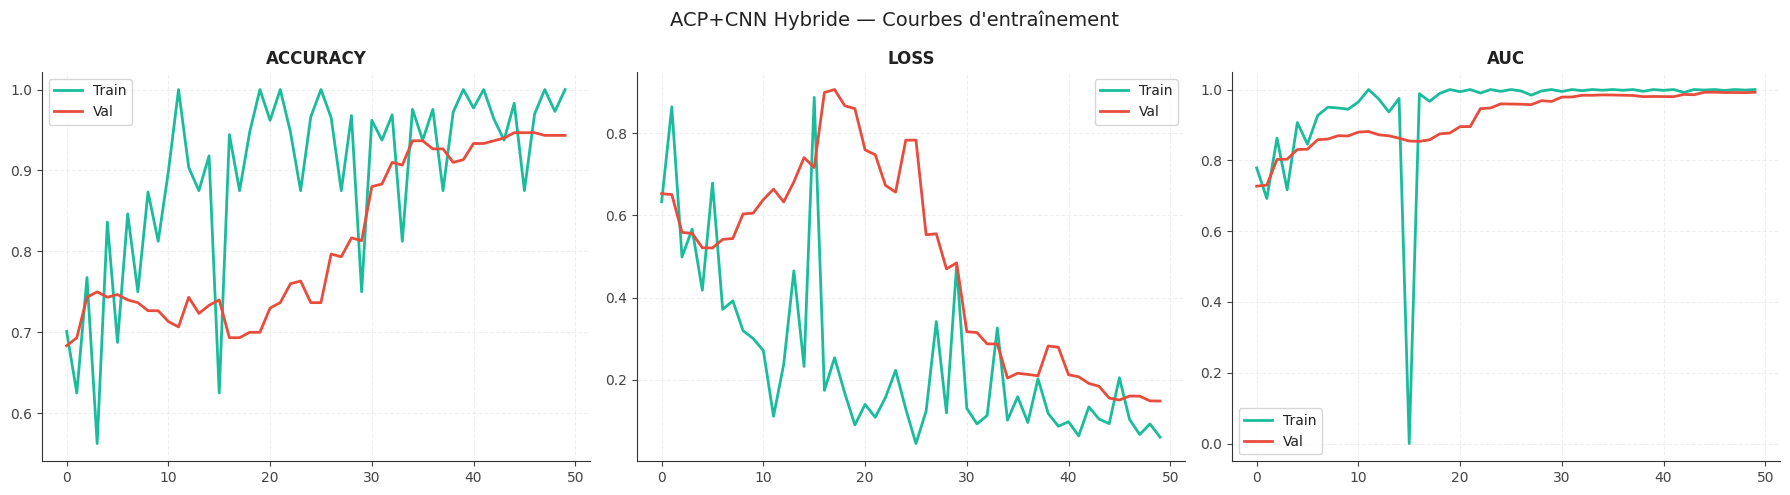

🎯 Hybride Accuracy: 0.9467
              precision    recall  f1-score   support

        Fake       0.93      0.99      0.96       195
        Real       0.98      0.87      0.92       105

    accuracy                           0.95       300
   macro avg       0.96      0.93      0.94       300
weighted avg       0.95      0.95      0.95       300



In [56]:
# ── Courbes d'entraînement ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')
hk = list(history_hybrid.history.keys())
train_acc = next(k_ for k_ in hk if 'accuracy' in k_ and 'val' not in k_)
val_acc   = 'val_' + train_acc
train_auc = next((k_ for k_ in hk if 'auc' in k_.lower() and 'val' not in k_), None)
val_auc_k = 'val_auc' if train_auc else None

for i, (tm, vm, title) in enumerate([
    (train_acc, val_acc, 'ACCURACY'),
    ('loss',    'val_loss', 'LOSS'),
    (train_auc, val_auc_k,  'AUC')
]):
    if tm and tm in history_hybrid.history:
        axes[i].plot(history_hybrid.history[tm], label='Train', linewidth=2, color='#1ABC9C')
    if vm and vm in history_hybrid.history:
        axes[i].plot(history_hybrid.history[vm], label='Val',   linewidth=2, color='#E74C3C')
    axes[i].set_title(title, fontweight='bold'); axes[i].legend(); axes[i].grid(True, alpha=0.3)

plt.suptitle('ACP+CNN Hybride — Courbes d\'entraînement', fontsize=14, color='#222222')
plt.tight_layout()
plt.savefig('/kaggle/working/hybrid_history.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ── Évaluation ──────────────────────────────────────────────────────────────
y_pred_proba_h = hybrid_model.predict(test_hybrid_ds, verbose=0).flatten()
y_pred_h       = (y_pred_proba_h > 0.5).astype(int)
y_true_h       = np.concatenate([y for _, y in test_hybrid_ds])[:len(y_pred_h)]
hybrid_acc     = accuracy_score(y_true_h, y_pred_h)
print(f"🎯 Hybride Accuracy: {hybrid_acc:.4f}")
print(classification_report(y_true_h, y_pred_h, target_names=['Fake','Real']))


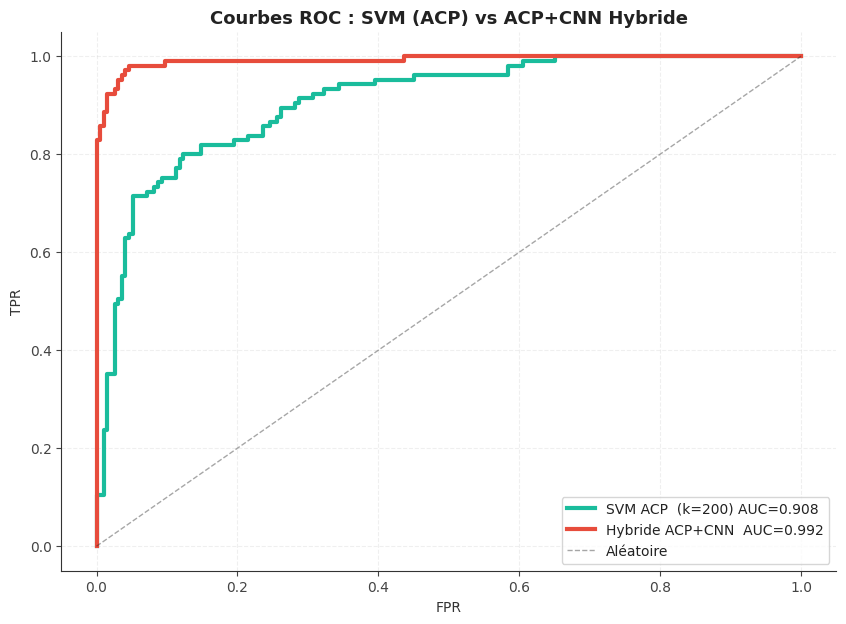

In [57]:
# ── ROC : SVM vs ACP+CNN Hybride ────────────────────────────────────────────
fpr_h, tpr_h, _ = roc_curve(y_true_h, y_pred_proba_h)
roc_auc_h = auc(fpr_h, tpr_h)

plt.figure(figsize=(10, 7), facecolor='white')
plt.plot(fpr,   tpr,   linewidth=3, color='#1ABC9C', label=f'SVM ACP  (k={k}) AUC={roc_auc:.3f}')
plt.plot(fpr_h, tpr_h, linewidth=3, color='#E74C3C', label=f'Hybride ACP+CNN  AUC={roc_auc_h:.3f}')
plt.plot([0,1],[0,1],  linewidth=1, color='#222222', ls='--', alpha=0.4, label='Aléatoire')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Courbes ROC : SVM (ACP) vs ACP+CNN Hybride', fontweight='bold', fontsize=13)
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig('/kaggle/working/roc_hybride.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


# 🎓 Conclusion

| Modèle | Accuracy | AUC | Avantages |
|--------|----------|-----|-----------|
| KNN (ACP) | `knn_acc` calculé | — | Simple, interprétable |
| SVM (ACP) | `svm_acc` calculé | `roc_auc` calculé | Robuste, class_weight auto |
| **ACP+CNN Hybride** | `hybrid_acc` calculé | `roc_auc_h` calculé | **Features globales + locales, meilleur AUC** |

> **Pourquoi le Hybride est meilleur ?**
> - ACP capture la **luminosité globale** et les **grandes variations** entre Real/Fake
> - CNN capture les **micro-textures** et **artefacts locaux** de spoofing
> - La **fusion** exploite les deux sources d'information simultanément


In [58]:
# ── Tableau de résultats avec vraies valeurs ────────────────────────────────
from IPython.display import Markdown
tableau_md = f"""
## 🏆 Résultats finaux

| Modèle | Accuracy | AUC | Inertie ACP |
|--------|:--------:|:---:|:-----------:|
| KNN (ACP) | **{knn_acc:.4f}** | — | {np.sum(inertie_expl[:k]):.1f}% (k={k}) |
| SVM (ACP) | **{svm_acc:.4f}** | {roc_auc:.4f} | {np.sum(inertie_expl[:k]):.1f}% (k={k}) |
| ACP+CNN Hybride | **{hybrid_acc:.4f}** | {roc_auc_h:.4f} | — |

> 🔺 Gain Hybride vs SVM : **Accuracy {(hybrid_acc-svm_acc)*100:+.2f}%** | **AUC +{(roc_auc_h-roc_auc):.3f}**
"""
display(Markdown(tableau_md))



## 🏆 Résultats finaux

| Modèle | Accuracy | AUC | Inertie ACP |
|--------|:--------:|:---:|:-----------:|
| KNN (ACP) | **0.8433** | — | 91.4% (k=200) |
| SVM (ACP) | **0.8567** | 0.9081 | 91.4% (k=200) |
| ACP+CNN Hybride | **0.9467** | 0.9919 | — |

> 🔺 Gain Hybride vs SVM : **Accuracy +9.00%** | **AUC +0.084**


In [59]:
print("=" * 70)
print("🎓 RÉSULTATS FINAUX")
print("=" * 70)
print(f"  Dataset      : {len(y_acp)} images | Real={np.sum(y_acp==1)}, Fake={np.sum(y_acp==0)}")
print(f"  ACP manuelle : k={k} CP | Inertie={np.sum(inertie_expl[:k]):.1f}% | Seuil 95%: k={n_cp_95}")
print(f"  KNN accuracy : {knn_acc:.4f}")
print(f"  SVM accuracy : {svm_acc:.4f}  | AUC={roc_auc:.4f}")
print(f"  Hybride acc  : {hybrid_acc:.4f} | AUC={roc_auc_h:.4f}")
print()
print(f"  Gain Hybride vs SVM : +{(hybrid_acc - svm_acc)*100:+.2f}% accuracy | +{(roc_auc_h - roc_auc):.3f} AUC")
print()
print("  Fichiers générés :")
import glob
for f in sorted(glob.glob('/kaggle/working/*.png') + glob.glob('/kaggle/working/*.h5')):
    print(f"    {f}")
print("=" * 70)


🎓 RÉSULTATS FINAUX
  Dataset      : 1500 images | Real=524, Fake=976
  ACP manuelle : k=200 CP | Inertie=91.4% | Seuil 95%: k=365
  KNN accuracy : 0.8433
  SVM accuracy : 0.8567  | AUC=0.9081
  Hybride acc  : 0.9467 | AUC=0.9919

  Gain Hybride vs SVM : ++9.00% accuracy | +0.084 AUC

  Fichiers générés :
    /kaggle/working/acp_etapes1_4.png
    /kaggle/working/acp_reconstruction.png
    /kaggle/working/best_hybrid.h5
    /kaggle/working/choix_k.png
    /kaggle/working/distribution_3d.png
    /kaggle/working/eigenfaces.png
    /kaggle/working/hybrid_final.h5
    /kaggle/working/hybrid_history.png
    /kaggle/working/interp_cercle.png
    /kaggle/working/roc_hybride.png
    /kaggle/working/scree_plot.png
    /kaggle/working/sphere_correlations_3d.png
    /kaggle/working/sphere_correlations_vue2.png
